# Mapping von Institutionen

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
kb = client.query(f"""
                    SELECT 
                        CASE 
                            -- WHEN kb_inst.ror = 'https://ror.org/021ft0n22' THEN 'Universitätsmedizin Göttingen' # in der KB-Kodierung als GAU kodiert
                            WHEN kb_inst.ror = 'https://ror.org/02w2y2t16' THEN 'Leuphana Universität Lüneburg'
                            WHEN kb_inst.ror = 'https://ror.org/033n9gh91' THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN kb_inst.ror = 'https://ror.org/02vvvm705' THEN 'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth'
                            WHEN kb_inst.ror = 'https://ror.org/01bc76c69' THEN 'Hochschule Emden/Leer'
                            WHEN kb_inst.ror = 'https://ror.org/0304hq317' THEN 'Gottfried Wilhelm Leibniz Universität Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/00x67m532' THEN 'Hochschule für Musik, Theater und Medien Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/03m2kj587' THEN 'Hochschule Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/015qjqf64' THEN 'Stiftung Tierärztliche Hochschule Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/00f2yqf98' THEN 'Medizinische Hochschule Hannover (MHH)'
                            WHEN kb_inst.ror = 'https://ror.org/00f5q5839' THEN 'HAWK Hochschule für angewandte Wissenschaft und Kunst'
                            WHEN kb_inst.ror = 'https://ror.org/02f9det96' THEN 'Stiftung Universität Hildesheim'
                            WHEN kb_inst.ror = 'https://ror.org/01y9bpm73' THEN 'Georg-August-Universität Göttingen'
                            WHEN kb_inst.ror = 'https://ror.org/010nsgg66' THEN 'Technische Universität Braunschweig'
                            WHEN kb_inst.ror = 'https://ror.org/03aft2f80' THEN 'Hochschule für Bildende Künste Braunschweig'
                            WHEN kb_inst.ror = 'https://ror.org/01bk10867' THEN 'Ostfalia Hochschule für angewandte Wissenschaften'
                            WHEN kb_inst.ror = 'https://ror.org/04qb8nc58' THEN 'Technische Universität Clausthal'
                            WHEN kb_inst.ror = 'https://ror.org/04qmmjx98' THEN 'Universität Osnabrück'
                            WHEN kb_inst.ror = 'https://ror.org/059vymd37' THEN 'Hochschule Osnabrück'
                            WHEN kb_inst.ror = 'https://ror.org/045y6d111' THEN 'Universität Vechta'
                            -- Ergänzung von Suborganisationen (Oldenburg)
                            WHEN inst_id = 445 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 6612 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 316 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 315 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 5488 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 4564 THEN 'Carl von Ossietzky Universität Oldenburg'
                            ELSE ''
                        END AS parent_name,
                        CASE 
                            -- Ergänzung von Suborganisationen (Oldenburg)
                            WHEN inst_id = 445 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 6612 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 316 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 315 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 5488 THEN 'Helmholtz-Institut für Funktionelle Marine Biodiversität'
                            WHEN inst_id = 4564 THEN 'Institute for Science Networking Oldenburg GmbH'
                            ELSE 'not assigned'
                        END AS fak_name,
                        inst.address_full AS raw_affiliation_string,
                        doi
                    FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                    JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                      ON inst.inst_id_top = kb_inst.inst_id
                    JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                        ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                    WHERE oal.type IN ('article', 'review') 
                        AND primary_location.source.type='journal'
                        AND is_paratext=FALSE 
                        AND is_retracted=FALSE 
                        AND is_xpac=FALSE
                        AND publication_year BETWEEN 2020 AND 2024
                        AND (kb_inst.ror IN (
                            'https://ror.org/021ft0n22', -- Universitätsmedizin Göttingen
                            'https://ror.org/02w2y2t16', -- Leuphana Universität Lüneburg
                            'https://ror.org/033n9gh91', -- Carl von Ossietzky Universität Oldenburg
                            'https://ror.org/02vvvm705', -- Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth
                            'https://ror.org/01bc76c69', -- Hochschule Emden/Leer
                            'https://ror.org/0304hq317', -- Gottfried Wilhelm Leibniz Universität Hannover
                            'https://ror.org/00x67m532', -- Hochschule für Musik, Theater und Medien Hannover
                            'https://ror.org/03m2kj587', -- Hochschule Hannover
                            'https://ror.org/015qjqf64', -- Stiftung Tierärztliche Hochschule Hannover
                            'https://ror.org/00f2yqf98', -- Medizinische Hochschule Hannover (MHH)
                            'https://ror.org/00f5q5839', -- HAWK Hochschule für angewandte Wissenschaft und Kunst
                            'https://ror.org/02f9det96', -- Stiftung Universität Hildesheim
                            'https://ror.org/01y9bpm73', -- Georg-August-Universität Göttingen
                            'https://ror.org/010nsgg66', -- Technische Universität Braunschweig
                            'https://ror.org/03aft2f80', -- Hochschule für Bildende Künste Braunschweig
                            'https://ror.org/01bk10867', -- Ostfalia Hochschule für angewandte Wissenschaften
                            'https://ror.org/04qb8nc58', -- Technische Universität Clausthal
                            'https://ror.org/04qmmjx98', -- Universität Osnabrück
                            'https://ror.org/059vymd37', -- Hochschule Osnabrück
                            'https://ror.org/045y6d111' -- Universität Vechta
                        ) OR kb_inst.inst_id IN (
                             -- Ergänzung von Suborganisationen (Oldenburg)
                             445, -- 'Evangelisches Krankenhaus Oldenburg'
                             6612, -- 'UMO - Universitätsmedizin Oldenburg'
                             316, -- 'Klinikum Oldenburg gGmbH'
                             315, -- 'Pius-Hospital Oldenburg'
                             5488, -- 'Helmholtz-Institut für Funktionelle Marine Biodiversität an der Universität Oldenburg (HIFMB)'
                             4564 -- Institute for Science Networking Oldenburg GmbH
                            )
                        )
                    ORDER BY fak_name
                    """).to_dataframe()

In [5]:
kb.replace({'Universitätsmedizin Oldenburg': 'Fakultät VI - Medizin und Gesundheitswissenschaften'}, inplace=True)

In [6]:
kb.head()

,parent_name,fak_name,raw_affiliation_string,doi
0,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Inst. for Functional Marine Biodiver...,10.1111/ecog.05869
1,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.1111/rec.13398
2,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.1111/jeu.13015
3,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Inst. for Functional Marine Biodiver...,10.1111/ecog.05869
4,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.1111/jeu.13015


In [7]:
with open('institution_mapping/mapping_tables_fak/clausthal.json', 'r') as file:
    CLAUSTHAL_MAPPING = json.load(file)

In [8]:
with open('institution_mapping/mapping_tables_fak/emden.json', 'r') as file:
    EMDEN_MAPPING = json.load(file)

In [9]:
with open('institution_mapping/mapping_tables_fak/gau.json', 'r') as file:
    GAU_MAPPING = json.load(file)

In [10]:
with open('institution_mapping/mapping_tables_fak/hawk.json', 'r') as file:
    HAWK_MAPPING = json.load(file)

In [11]:
with open('institution_mapping/mapping_tables_fak/hbk.json', 'r') as file:
    HBK_MAPPING = json.load(file)

In [12]:
with open('institution_mapping/mapping_tables_fak/hildesheim.json', 'r') as file:
    HILDESHEIM_MAPPING = json.load(file)

In [13]:
with open('institution_mapping/mapping_tables_fak/hmtmh.json', 'r') as file:
    HMTMH_MAPPING = json.load(file)

In [14]:
with open('institution_mapping/mapping_tables_fak/hsh.json', 'r') as file:
    HSH_MAPPING = json.load(file)

In [15]:
with open('institution_mapping/mapping_tables_fak/hsosnabrueck.json', 'r') as file:
    HSOSNABRÜCK_MAPPING = json.load(file)

In [16]:
with open('institution_mapping/mapping_tables_fak/jade.json', 'r') as file:
    JADE_MAPPING = json.load(file)

In [17]:
with open('institution_mapping/mapping_tables_fak/leibniz.json', 'r') as file:
    LEIBNIZ_MAPPING = json.load(file)

In [18]:
with open('institution_mapping/mapping_tables_fak/leuphana.json', 'r') as file:
    LEUPHANA_MAPPING = json.load(file)

In [19]:
with open('institution_mapping/mapping_tables_fak/mhh.json', 'r') as file:
    MHH_MAPPING = json.load(file)

In [20]:
with open('institution_mapping/mapping_tables_fak/oldenburg.json', 'r') as file:
    OLDENBURG_MAPPING = json.load(file)

In [21]:
with open('institution_mapping/mapping_tables_fak/ostfalia.json', 'r') as file:
    OSTFALIA_MAPPING = json.load(file)

In [22]:
with open('institution_mapping/mapping_tables_fak/tiho.json', 'r') as file:
    TIHO_MAPPING = json.load(file)

In [23]:
with open('institution_mapping/mapping_tables_fak/tubraunschweig.json', 'r') as file:
    TUBRAUNSCHWEIG_MAPPING = json.load(file)

In [24]:
with open('institution_mapping/mapping_tables_fak/uosnabrueck.json', 'r') as file:
    UOSNABRÜCK_MAPPING = json.load(file)

In [25]:
with open('institution_mapping/mapping_tables_fak/vechta.json', 'r') as file:
    VECHTA_MAPPING = json.load(file)

In [26]:
MAPPING_DICT_FAK = {
    'Technische Universität Clausthal': CLAUSTHAL_MAPPING,
    'Hochschule Emden/Leer': EMDEN_MAPPING,
    'Georg-August-Universität Göttingen': GAU_MAPPING,
    'HAWK Hochschule für angewandte Wissenschaft und Kunst': HAWK_MAPPING,
    'Hochschule für Bildende Künste Braunschweig': HBK_MAPPING,
    'Stiftung Universität Hildesheim': HILDESHEIM_MAPPING,
    'Hochschule für Musik, Theater und Medien Hannover': HMTMH_MAPPING,
    'Hochschule Hannover': HSH_MAPPING,
    'Hochschule Osnabrück': HSOSNABRÜCK_MAPPING,
    'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth': JADE_MAPPING,
    'Gottfried Wilhelm Leibniz Universität Hannover': LEIBNIZ_MAPPING,
    'Leuphana Universität Lüneburg': LEUPHANA_MAPPING,
    'Medizinische Hochschule Hannover (MHH)': MHH_MAPPING,
    'Carl von Ossietzky Universität Oldenburg': OLDENBURG_MAPPING,
    'Ostfalia Hochschule für angewandte Wissenschaften': OSTFALIA_MAPPING,
    'Stiftung Tierärztliche Hochschule Hannover': TIHO_MAPPING,
    'Technische Universität Braunschweig': TUBRAUNSCHWEIG_MAPPING,
    'Universität Osnabrück': UOSNABRÜCK_MAPPING,
    'Universität Vechta': VECHTA_MAPPING
}

In [27]:
map_df = kb.copy()

In [28]:
def map_fak(address: str, mapping_dict: dict) -> Union[str, None]:
    for k, v in mapping_dict.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [29]:
def map_umg(address: str) -> Union[str, None]:
    with open('institution_mapping/mapping_tables_dept/gau.json', 'r') as file:
        MAPPING_DICT_DEPT = json.load(file)
    for k, v in MAPPING_DICT_DEPT.get('Universitätsmedizin Göttingen (UMG)').items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [30]:
for k, v in MAPPING_DICT_FAK.items():
    map_df.loc[map_df['parent_name'] == k, 'fak_name'] = \
        map_df.loc[map_df['parent_name'] == k]['raw_affiliation_string'].apply(map_fak, mapping_dict=v)

In [31]:
map_df.loc[map_df.fak_name == 'Universitätsmedizin Göttingen (UMG)', 'parent_name'] = 'Universitätsmedizin Göttingen'
map_df.loc[map_df.parent_name == 'Universitätsmedizin Göttingen', 'fak_name'] = 'not assigned'

In [32]:
map_df.loc[map_df['parent_name'] == 'Universitätsmedizin Göttingen', 'fak_name'] = \
    map_df.loc[map_df['parent_name'] == 'Universitätsmedizin Göttingen']['raw_affiliation_string'].apply(map_umg)

In [33]:
map_df.head()

,parent_name,fak_name,raw_affiliation_string,doi
0,Carl von Ossietzky Universität Oldenburg,Fakultät V - Mathematik und Naturwissenschaften,Helmholtz Inst. for Functional Marine Biodiver...,10.1111/ecog.05869
1,Carl von Ossietzky Universität Oldenburg,Fakultät V - Mathematik und Naturwissenschaften,Helmholtz Institute for Functional Marine Biod...,10.1111/rec.13398
2,Carl von Ossietzky Universität Oldenburg,Fakultät V - Mathematik und Naturwissenschaften,Helmholtz Institute for Functional Marine Biod...,10.1111/jeu.13015
3,Carl von Ossietzky Universität Oldenburg,Fakultät V - Mathematik und Naturwissenschaften,Helmholtz Inst. for Functional Marine Biodiver...,10.1111/ecog.05869
4,Carl von Ossietzky Universität Oldenburg,Fakultät V - Mathematik und Naturwissenschaften,Helmholtz Institute for Functional Marine Biod...,10.1111/jeu.13015


In [34]:
liste_aller_hochschulen = list(map_df.parent_name.unique())

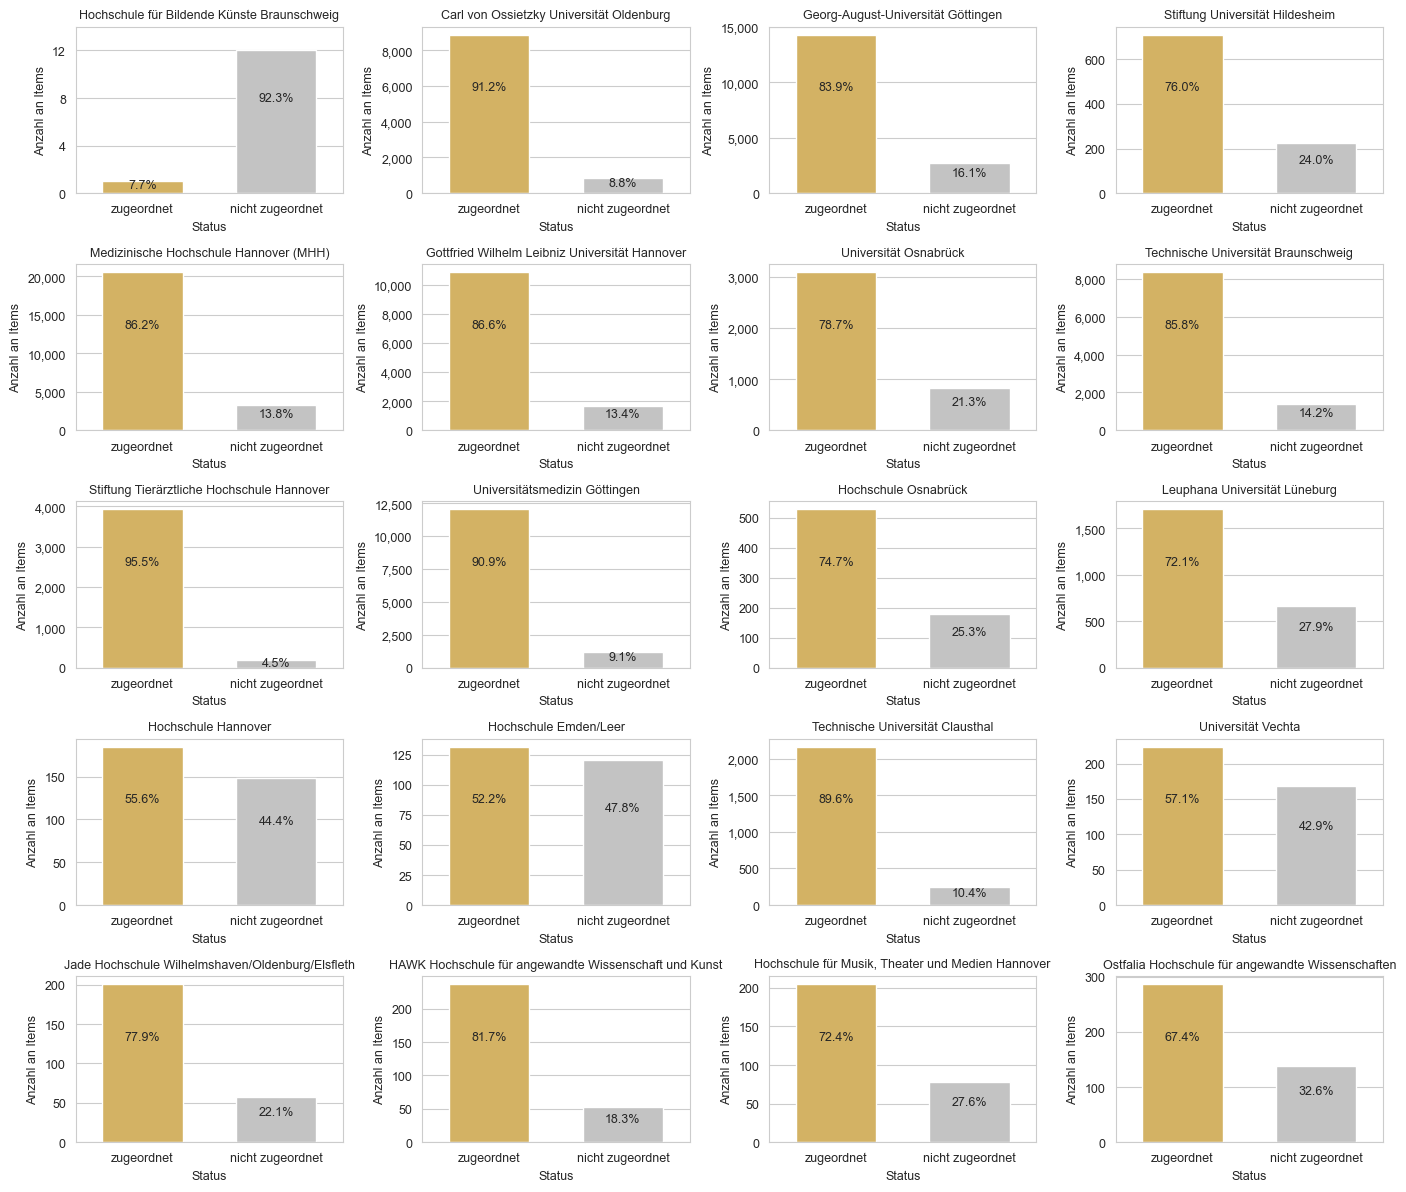

In [35]:
fig, axes = plt.subplots(nrows=5, 
                         ncols=4, 
                         sharex=False, 
                         sharey=False, 
                         figsize=(14,12))

axes = axes.reshape(-1)

for i, ax in enumerate(axes, 0):

    parent_name = liste_aller_hochschulen[i-1]

    df_temp = map_df[map_df.parent_name == parent_name].copy()
    df_temp.fillna('Nicht zugeordnet', inplace=True)

    number_of_items_mapped = df_temp[df_temp.fak_name != 'Nicht zugeordnet'].doi.count()
    number_of_items_not_mapped = df_temp[df_temp.fak_name == 'Nicht zugeordnet'].doi.count()

    prop = df_temp[df_temp.fak_name != 'Nicht zugeordnet'].doi.count() / df_temp.doi.count()

    data = {
        'mapped_indicator': ['zugeordnet', 'nicht zugeordnet'],
        'n': [number_of_items_mapped, number_of_items_not_mapped],
        'prop': [format(prop, '.1%'), format(1-prop, '.1%')]
    }
    
    df = pd.DataFrame(data)
    
    sns.barplot(data=df, 
                x='mapped_indicator', 
                y='n', 
                width=0.6,
                hue='mapped_indicator',
                palette=['#E5BA52', '#c3c3c3'],
                ax=ax).set_title(parent_name, fontdict=dict(fontsize=9, fontweight=500))

    for idx, row in df.iterrows():
        ax.text(row['mapped_indicator'], 
                row['n'] / 1.5, 
                row['prop'], 
                verticalalignment='center', 
                horizontalalignment='center', 
                fontdict=dict(fontsize=9, fontweight=500))

    if parent_name == 'Hochschule für Bildende Künste Braunschweig':
        ax.set_ylim(0, 14)
        ax.set_yticks(range(0, 15, 4))

    ax.set(xlabel='Status', ylabel='Anzahl an Items')

    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()

plt.show()
fig.savefig('mapping.png', format='png', bbox_inches='tight', dpi=600)

In [36]:
map_df.sample(10)

,parent_name,fak_name,raw_affiliation_string,doi
20324,Medizinische Hochschule Hannover (MHH),Zentrum für Kinderheilkunde und Jugendmedizin,"Department of Paediatric Pneumology, Allergolo...",10.1111/all.16388
7273,Carl von Ossietzky Universität Oldenburg,Fakultät VI - Medizin und Gesundheitswissensch...,Abteilung Organisationsbezogene Versorgungsfor...,10.1007/s00481-022-00708-8
7327,Medizinische Hochschule Hannover (MHH),Zentrum Innere Medizin,"Klinik für Nieren- und Hochdruckerkrankungen, ...",10.1007/s11560-024-00817-z
16859,Technische Universität Braunschweig,Fakultät für Maschinenbau,"Technische Universität Braunschweig, Institute...",10.1016/j.ast.2024.108913
91509,Universitätsmedizin Göttingen,Exzellenzcluster Multiscale Bioimaging,Cluster of Excellence `Multiscale Bioimaging: ...,10.1107/s1600577523002011
76597,Hochschule Hannover,"Fakultät V - Diakonie, Gesundheit und Soziales","Division Nursing and Health, Department V - So...",10.1186/s12913-021-07100-0
87443,Gottfried Wilhelm Leibniz Universität Hannover,Naturwissenschaftliche Fakultät,"Institute of Plant Genetics, Leibniz Universit...",10.3390/nu15030783
35461,Carl von Ossietzky Universität Oldenburg,Fakultät V - Mathematik und Naturwissenschaften,Institute for Chemistry and Biology of the Mar...,10.1103/physreve.109.014312
100683,Medizinische Hochschule Hannover (MHH),"Zentrum für Pathologie, Forensik und Genetik","Hannover Medical School, Institute of Patholog...",10.1080/15513815.2020.1792594
66995,Medizinische Hochschule Hannover (MHH),"Zentrum für Pathologie, Forensik und Genetik","Department of Human Genetics, Hannover Medical...",10.1016/j.scr.2021.102579
